# Loan Approval Project

## Loading Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

## Data Loading and Preprocessing

In [2]:
TRAIN_SET_PATH = '../data/train.csv'
train_df = pd.read_csv(TRAIN_SET_PATH, index_col='id')

In [3]:
train_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
id,,,,,,,,,,,,
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [4]:
train_df.rename(columns={'cb_person_default_on_file': 'cb_defaulter_on_file'}, inplace=True)

In [5]:
train_df.shape

(58645, 12)

In [6]:
train_df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_defaulter_on_file          0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  object 
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  object 
 5   loan_grade                  58645 non-null  object 
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_defaulter_on_file        58645 non-null  object 
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 5.8+ MB


In [8]:
train_df.person_home_ownership.value_counts()  # Onehot

person_home_ownership
RENT        30594
MORTGAGE    24824
OWN          3138
OTHER          89
Name: count, dtype: int64

In [9]:
train_df.cb_defaulter_on_file.value_counts()  # Label

cb_defaulter_on_file
N    49943
Y     8702
Name: count, dtype: int64

In [10]:
train_df.loan_intent.value_counts()   # One-Hot

loan_intent
EDUCATION            12271
MEDICAL              10934
PERSONAL             10016
VENTURE              10011
DEBTCONSOLIDATION     9133
HOMEIMPROVEMENT       6280
Name: count, dtype: int64

In [11]:
train_df.loan_grade.value_counts()  # Ordinal

loan_grade
A    20984
B    20400
C    11036
D     5034
E     1009
F      149
G       33
Name: count, dtype: int64

## Feature Engineering

In [12]:
onehot_enc_cols = ['loan_intent', 'person_home_ownership']
ord_enc_cols = ['loan_grade']
label_enc_cols =['cb_defaulter_on_file']

In [13]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
ord_enc = OrdinalEncoder()
lab_enc = LabelEncoder()

In [14]:
ord_encoded_cols = ord_enc.fit_transform(train_df[ord_enc_cols])

In [15]:
onehot_enc_df = pd.get_dummies(train_df[onehot_enc_cols], dtype=int)

In [16]:
train_df = train_df.join(onehot_enc_df, on='id', how='outer')

In [17]:
train_df.drop(onehot_enc_cols, axis=1, inplace=True)

In [18]:
train_df['loan_grade'] = ord_encoded_cols

In [19]:
train_df['cb_defaulter_on_file'] = lab_enc.fit_transform(np.ravel(train_df[label_enc_cols]))

In [20]:
loan_status = train_df.pop('loan_status')

In [21]:
train_df.insert(len(train_df.columns), 'loan_status', loan_status)

In [22]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58645 entries, 0 to 58644
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      58645 non-null  int64  
 1   person_income                   58645 non-null  int64  
 2   person_emp_length               58645 non-null  float64
 3   loan_grade                      58645 non-null  float64
 4   loan_amnt                       58645 non-null  int64  
 5   loan_int_rate                   58645 non-null  float64
 6   loan_percent_income             58645 non-null  float64
 7   cb_defaulter_on_file            58645 non-null  int64  
 8   cb_person_cred_hist_length      58645 non-null  int64  
 9   loan_intent_DEBTCONSOLIDATION   58645 non-null  int64  
 10  loan_intent_EDUCATION           58645 non-null  int64  
 11  loan_intent_HOMEIMPROVEMENT     58645 non-null  int64  
 12  loan_intent_MEDICAL             58645

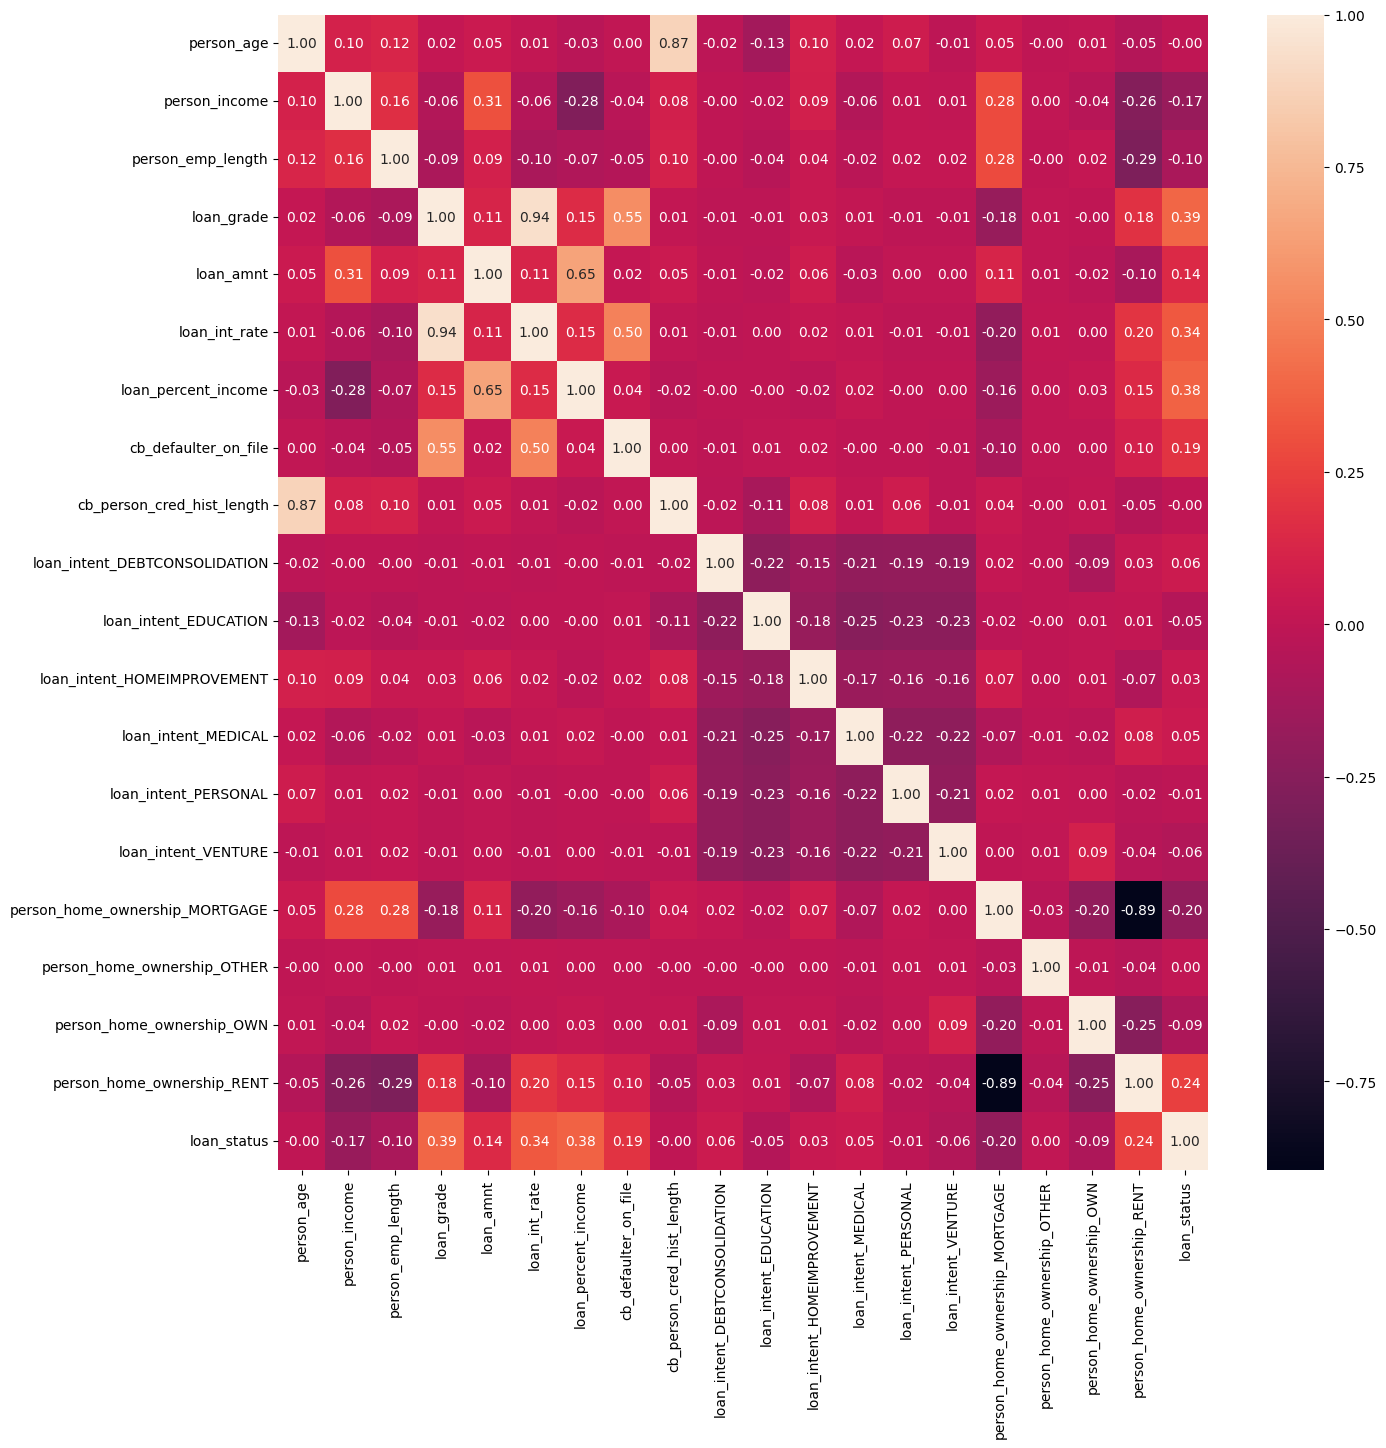

In [23]:
corr_matrix = train_df.corr(numeric_only=True)

plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()

In [24]:
drop_cols = ['person_age', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER']

In [25]:
from sklearn.feature_selection import mutual_info_regression
X = train_df.drop(['loan_status'], axis=1)
Y = train_df['loan_status']

In [26]:
mi_scores = mutual_info_regression(X, Y, random_state=42, n_jobs=-1)

In [27]:
mi_scores_df = pd.DataFrame({'Features': X.columns, 'MI Scores': mi_scores}).sort_values(by='MI Scores', ascending=False)

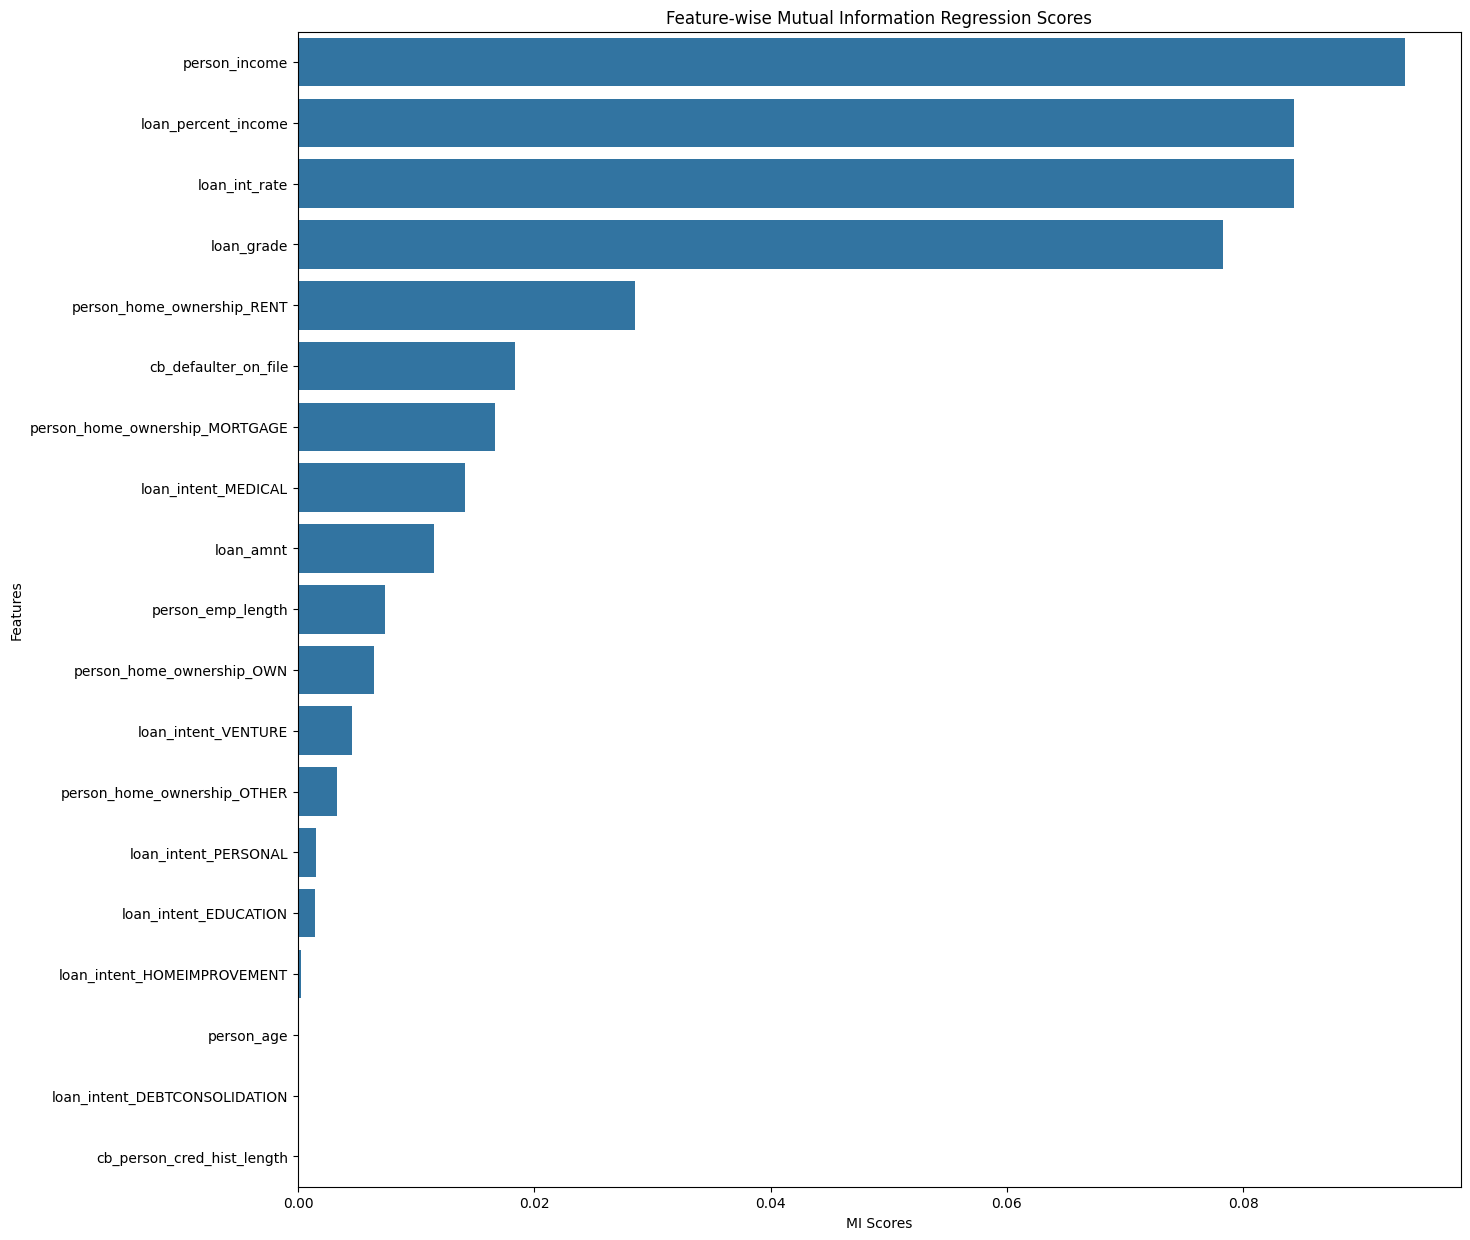

In [28]:
plt.figure(figsize=(15, 15))
plt.title('Feature-wise Mutual Information Regression Scores')

sns.barplot(mi_scores_df, x='MI Scores', y='Features')
plt.savefig('../reports/mutual_information_regression_scores.png')

In [29]:
train_df.drop(train_df.filter(regex='loan_intent_').columns, axis=1, inplace=True)

In [30]:
train_df.drop(drop_cols, axis=1, inplace=True)

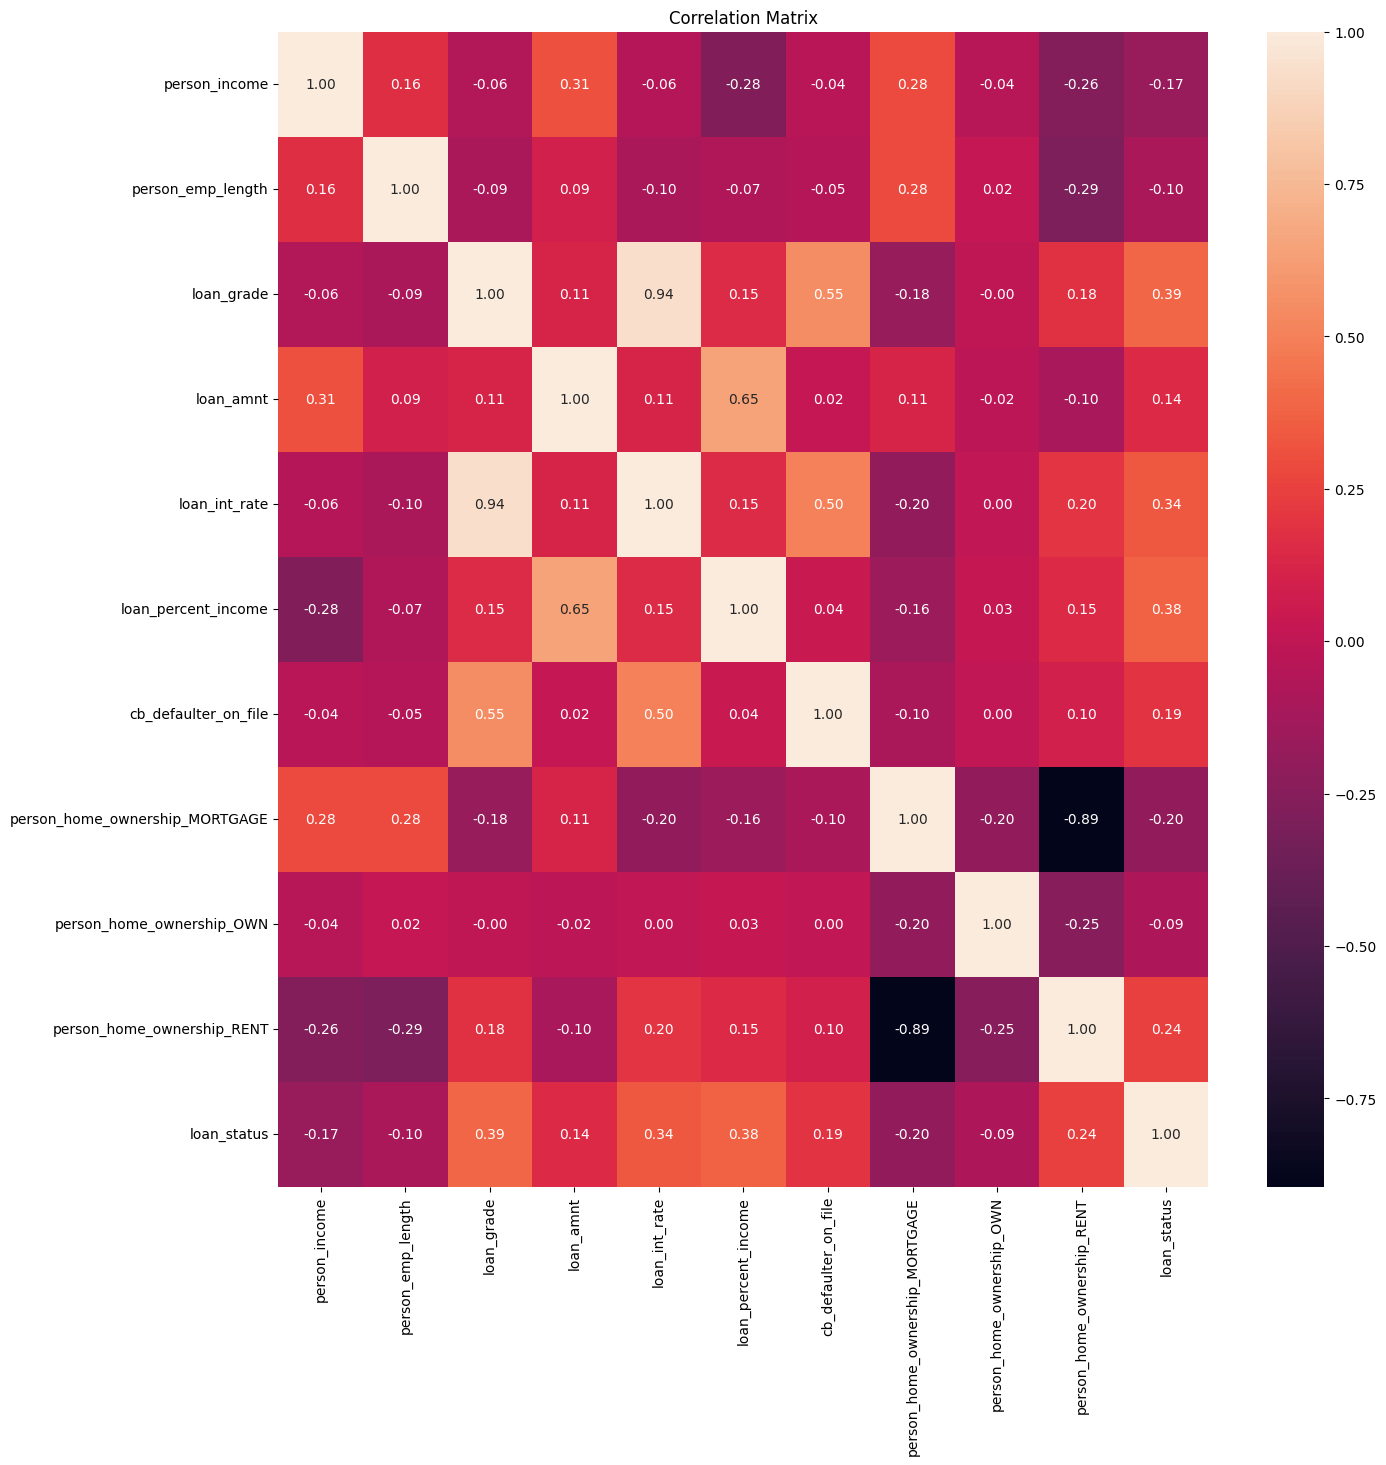

In [31]:
corr_matrix = train_df.corr(numeric_only=True)

plt.figure(figsize=(15,15))
plt.title('Correlation Matrix')

sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.savefig('../reports/Correlation_Matrix.png')

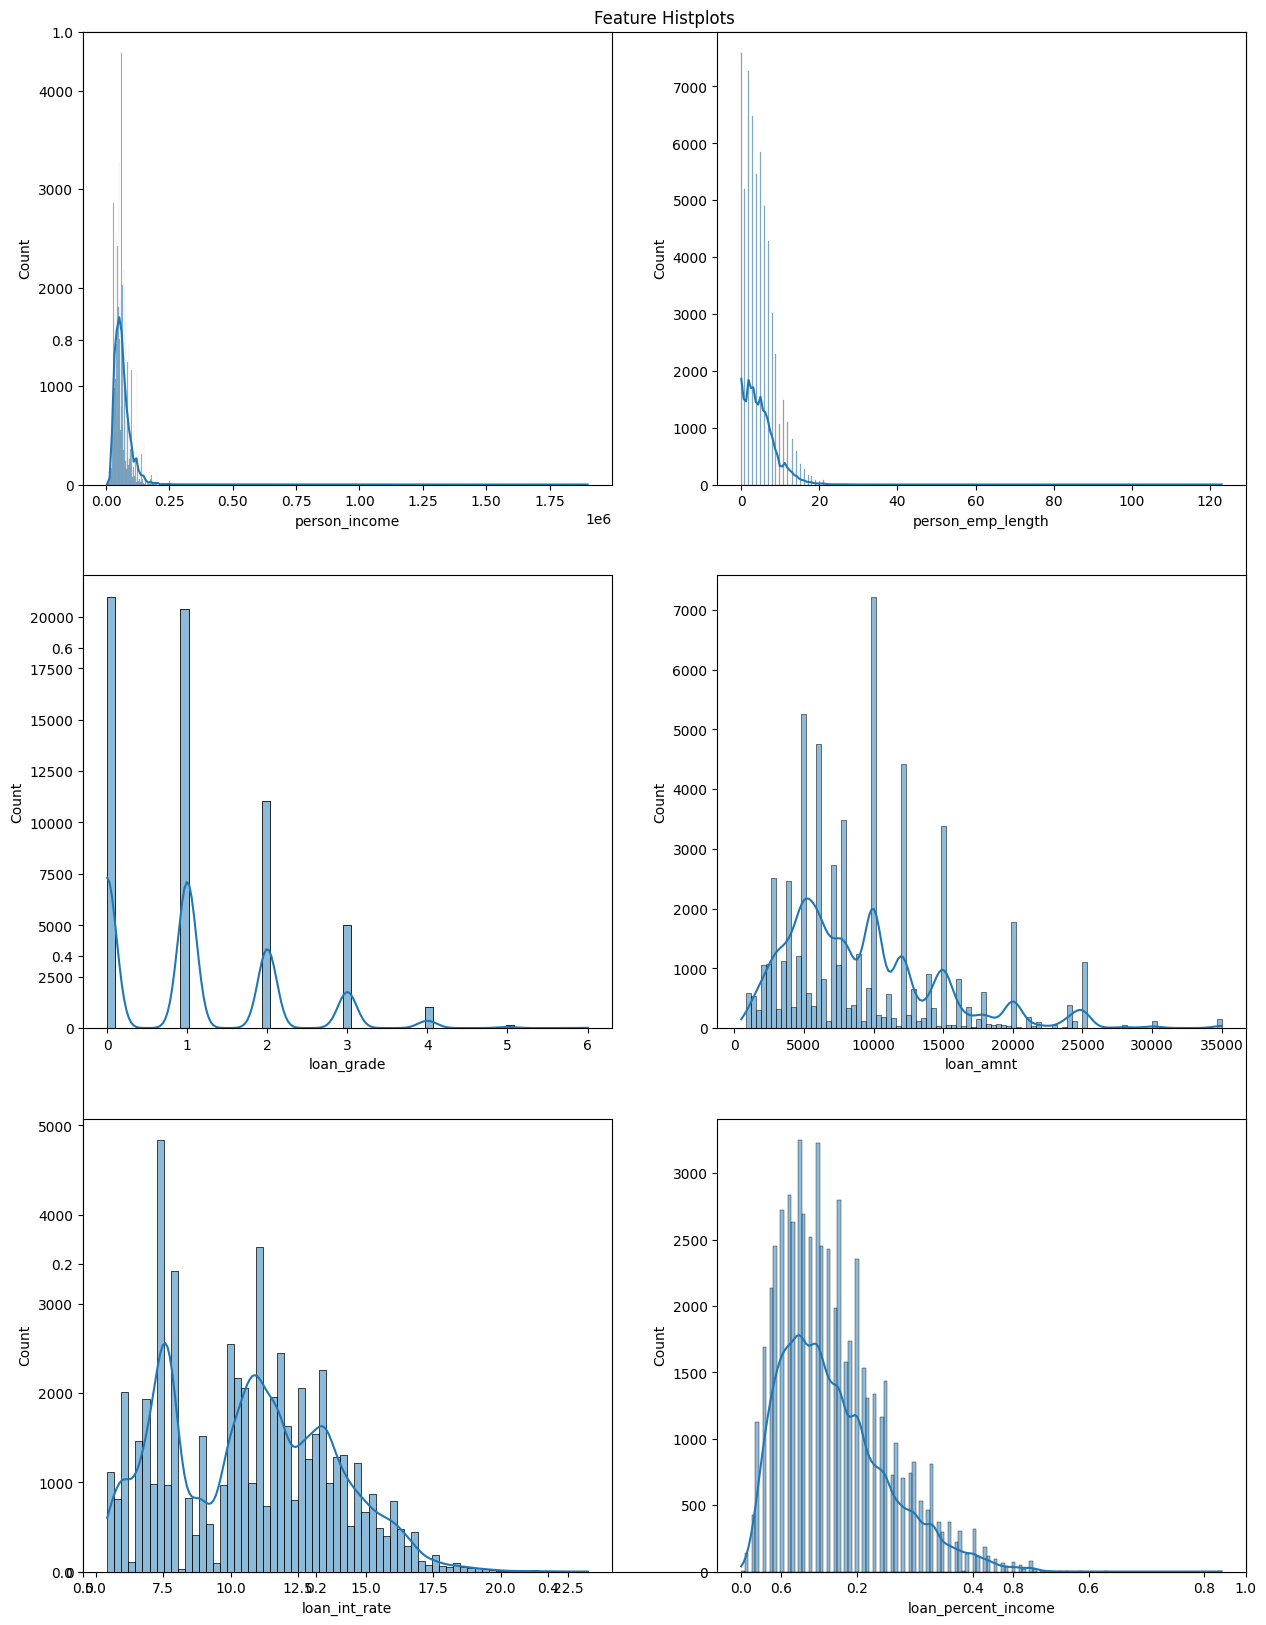

In [32]:
plt.figure(figsize=(15,20))
plt.title('Feature Histplots')

for i, col in enumerate(train_df.columns):
    if i > 5:
        continue
    else:
        plt.subplot(3, 2, i+1)
        sns.histplot(train_df[col], kde=True)
        # plt.title(f'{col}')
        
plt.savefig('../reports/feature-histplots.png')

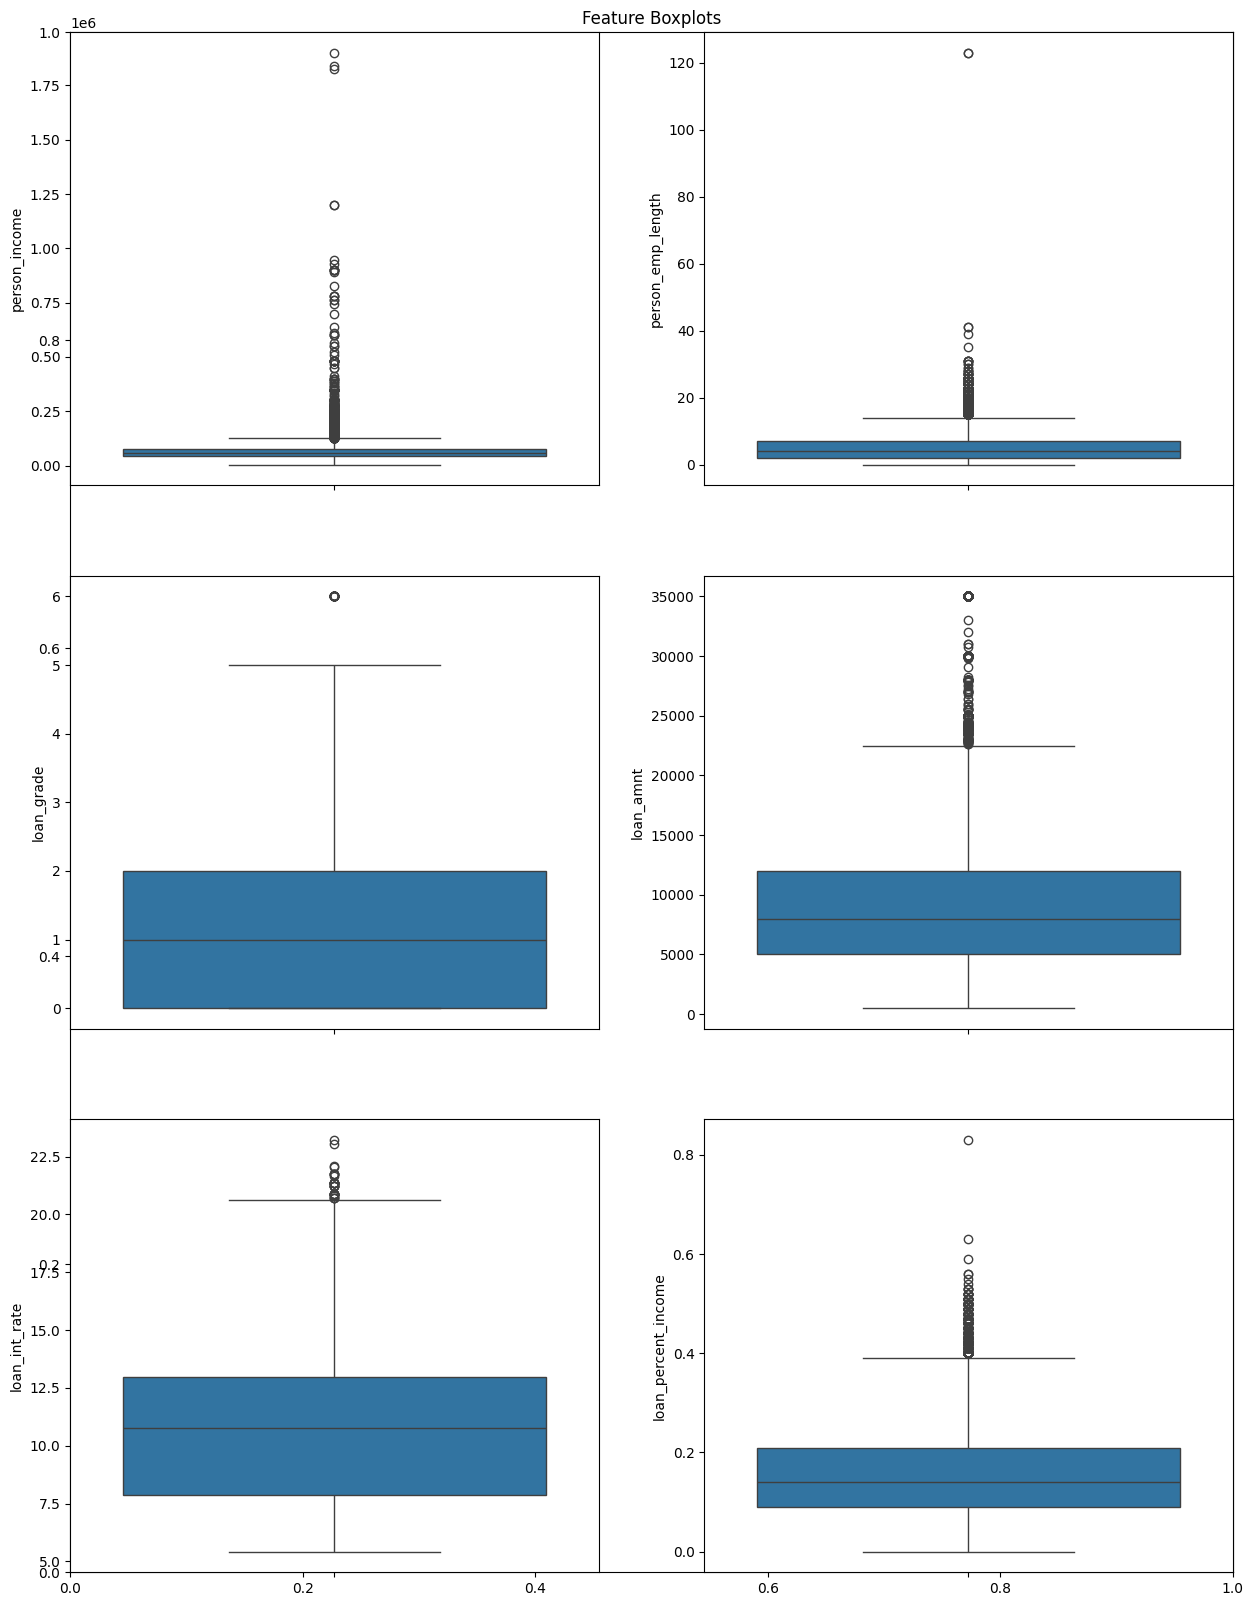

In [33]:
plt.figure(figsize=(15,20))
plt.title('Feature Boxplots')

for i, col in enumerate(train_df.columns):
    if i > 5:
        continue
    else:
        plt.subplot(3, 2, i+1)
        sns.boxplot(train_df[col])
        
plt.savefig('../reports/feature-boxplots.png')

## Model Training

In [34]:
from sklearn.model_selection import train_test_split
X = train_df.drop('loan_status', axis=1)
Y = train_df.loan_status

In [35]:
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.25, random_state=42)

In [36]:
from sklearn.preprocessing import QuantileTransformer
transformer = QuantileTransformer()

In [37]:
x_train_tfd = transformer.fit_transform(x_train)
x_val_tfd = transformer.transform(x_val)

In [38]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [39]:
rfc = RandomForestClassifier(random_state=42)
hgbc = HistGradientBoostingClassifier(random_state=42)
knc = KNeighborsClassifier()
lr = LogisticRegression()
svc = LinearSVC()

In [40]:
rfc.fit(x_train_tfd, y_train)
hgbc.fit(x_train_tfd, y_train)
knc.fit(x_train_tfd, y_train)
lr.fit(x_train_tfd, y_train)
svc.fit(x_train_tfd, y_train)

LinearSVC()

## Model Validation and Saving

In [41]:
rfc_preds = rfc.predict(x_val_tfd)
hgbc_preds = hgbc.predict(x_val_tfd)
knc_preds = knc.predict(x_val_tfd)
lr_preds = lr.predict(x_val_tfd)
svc_preds = svc.predict(x_val_tfd)

In [42]:
from sklearn.metrics import accuracy_score

In [43]:
print(f'RandomForestClassifier accuracy: {round(accuracy_score(y_val, rfc_preds), 4)*100} %')
print(f'HistGradientBoostingClassifier accuracy: {round(accuracy_score(y_val, hgbc_preds), 4)*100} %')
print(f'KNeighborsClassifier accuracy: {round(accuracy_score(y_val, knc_preds), 4)*100} %')
print(f'LogisticRegression accuracy: {round(accuracy_score(y_val, lr_preds), 4)*100} %')
print(f'Linear SupportVectorClassifier accuracy: {round(accuracy_score(y_val, svc_preds), 4)*100} %')

RandomForestClassifier accuracy: 93.54 %
HistGradientBoostingClassifier accuracy: 93.96 %
KNeighborsClassifier accuracy: 91.95 %
LogisticRegression accuracy: 88.69 %
Linear SupportVectorClassifier accuracy: 88.53 %


In [44]:
from pickle import dump

with open('../models/trained_RFC.joblib', 'wb') as f:
    dump(rfc, f)

with open('../models/trained_HGBC.joblib', 'wb') as f:
    dump(hgbc, f)

with open('../models/trained_KNC.joblib', 'wb') as f:
    dump(knc, f)

In [45]:
with open('../models/quantile_transformer.joblib', 'wb') as f:
    dump(transformer, f)

with open('../models/ordinal_encoder.joblib', 'wb') as f:
    dump(ord_enc, f)

with open('../models/label_encoder.joblib', 'wb') as f:
    dump(lab_enc, f)

In [46]:
from sklearn.metrics import confusion_matrix

In [47]:
cm_rfc = confusion_matrix(y_val, rfc_preds)
cm_hgbc = confusion_matrix(y_val, hgbc_preds)
cm_knc = confusion_matrix(y_val, knc_preds)
cm_lr = confusion_matrix(y_val, lr_preds)
cm_svc = confusion_matrix(y_val, svc_preds)

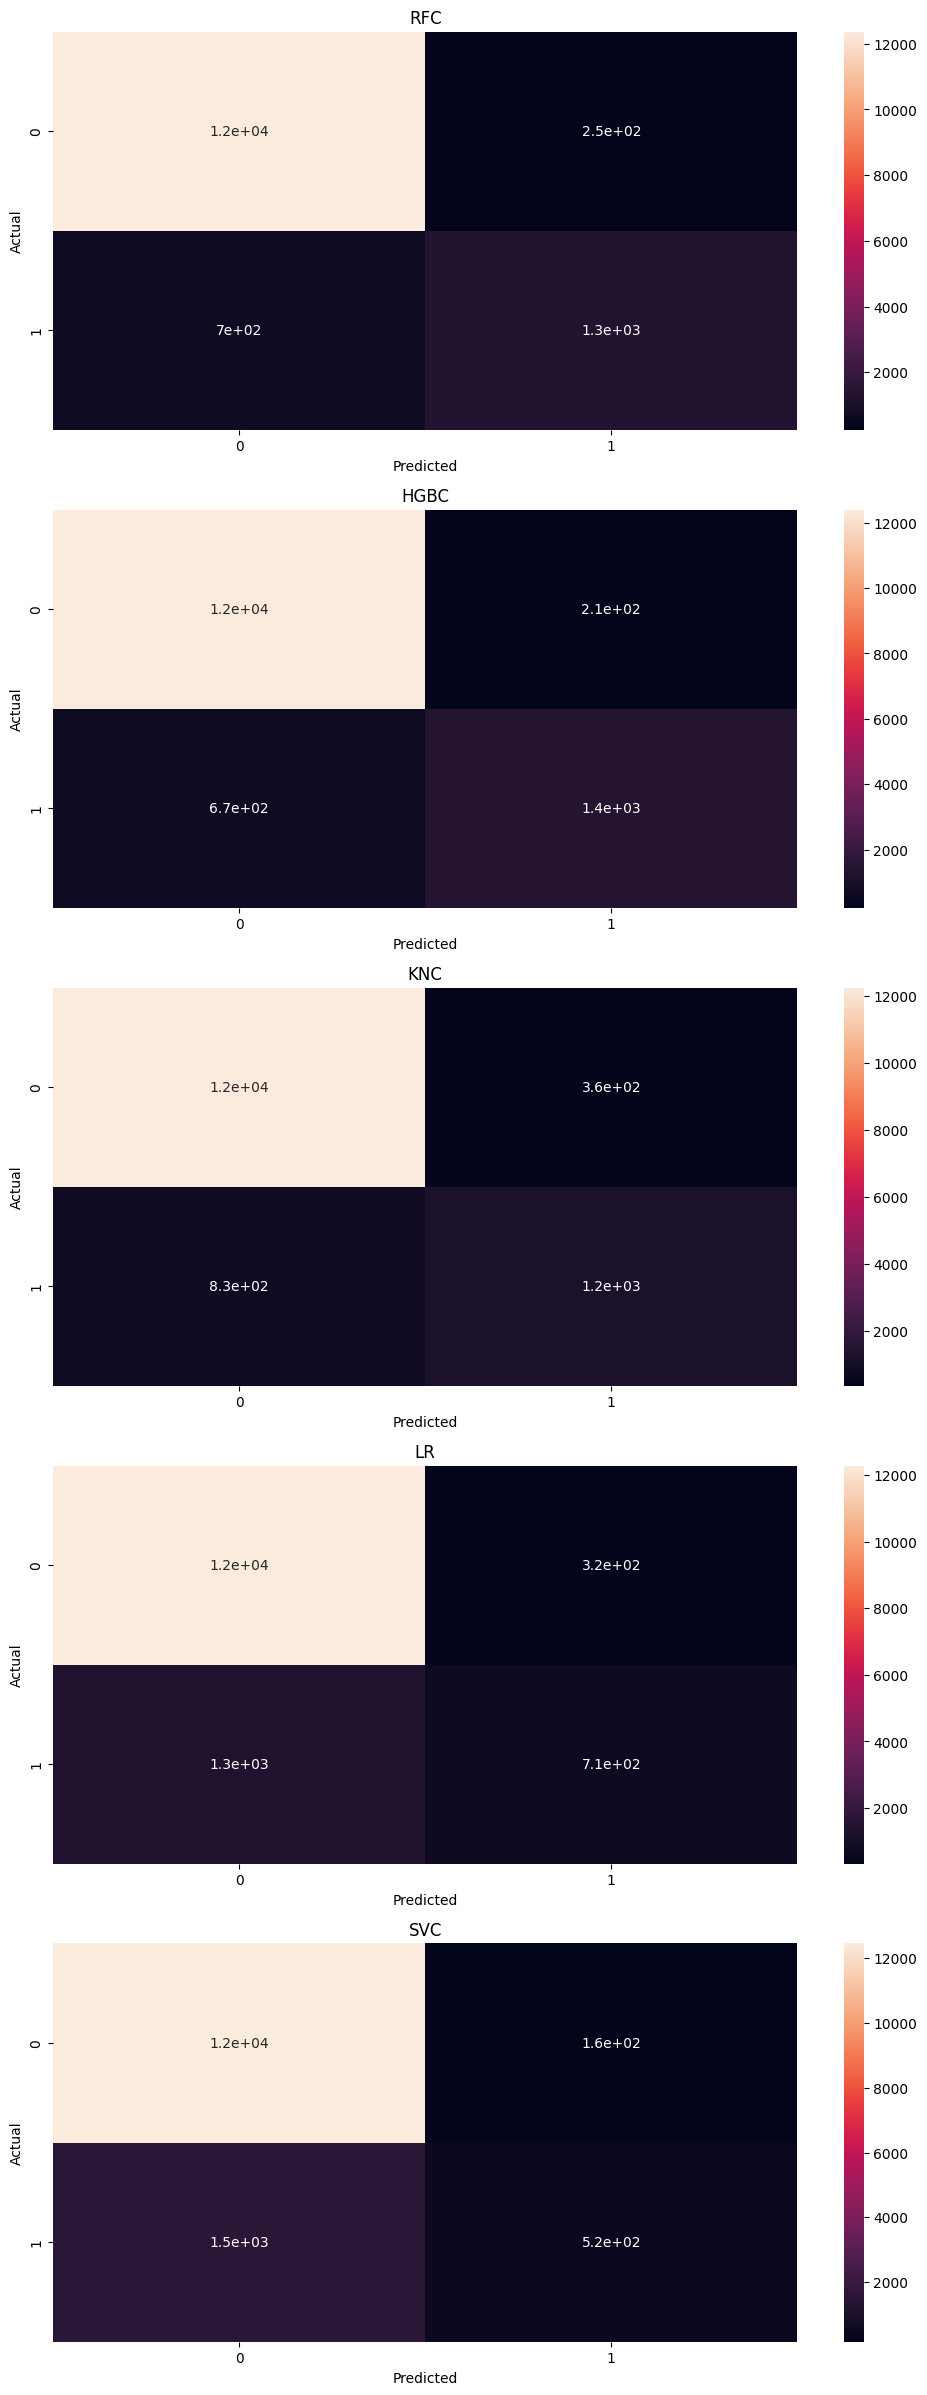

In [48]:
cms = {'RFC': cm_rfc, 'HGBC': cm_hgbc, 'KNC': cm_knc, 'LR': cm_lr, 'SVC': cm_svc}

plt.figure(figsize=(12, 30))

for i, cm in enumerate(cms.items()):
    plt.subplot(5, 1, i+1)
    sns.heatmap(cm[1], annot=True)
    plt.title(cm[0])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.savefig('../reports/confusion_matrices.png')